In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.channel import *
from src.grouping import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
M = 1000
Q = 250

h_BI_init, h_IU_init = generate_channels(M)

cascaded_init = h_BI_init * h_IU_init

static_groups = phase_grouping(
    cascaded_init,
    Q
)

dynamic_groups = phase_grouping(
    cascaded_init,
    Q
)

num_slots = 50

static_gains = []

dynamic_gains = []

h_BI = h_BI_init.copy()
h_IU = h_IU_init.copy()

In [3]:
for t in range(num_slots):

    # Channel evolution

    noise_BI, noise_IU = generate_channels(M)

    rho = 0.98

    h_BI = (
        rho*h_BI
        +
        np.sqrt(1-rho**2)*noise_BI
    )

    h_IU = (
        rho*h_IU
        +
        np.sqrt(1-rho**2)*noise_IU
    )

    cascaded = h_BI * h_IU

    # -------------------
    # STATIC
    # -------------------

    h_static = grouped_channel(
        h_BI,
        h_IU,
        static_groups
    )

    static_gains.append(
        abs(h_static)**2
    )

    # -------------------
    # DYNAMIC
    # -------------------

    dynamic_groups = phase_grouping(
        cascaded,
        Q
    )

    h_dynamic = grouped_channel(
        h_BI,
        h_IU,
        dynamic_groups
    )

    dynamic_gains.append(
        abs(h_dynamic)**2
    )

    print(
        "Initial Static Gain:",
        static_gains[0]
    )

    print(
        "Final Static Gain:",
        static_gains[-1]
    )

    print(
        "Initial Dynamic Gain:",
        dynamic_gains[0]
    )

    print(
        "Final Dynamic Gain:",
        dynamic_gains[-1]
    )

Initial Static Gain: 559127.0513865419
Final Static Gain: 559127.0513865419
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 594198.290750224
Initial Static Gain: 559127.0513865419
Final Static Gain: 511706.0046435136
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 582558.5324986584
Initial Static Gain: 559127.0513865419
Final Static Gain: 490672.3510310275
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 594909.8569732638
Initial Static Gain: 559127.0513865419
Final Static Gain: 471813.20774983964
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 612644.3264448912
Initial Static Gain: 559127.0513865419
Final Static Gain: 453375.3405543223
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 625581.252799057
Initial Static Gain: 559127.0513865419
Final Static Gain: 420082.33604289434
Initial Dynamic Gain: 594198.290750224
Final Dynamic Gain: 613183.5374717963
Initial Static Gain: 559127.0513865419
Final Static Gain: 382546.11967350525
Initi

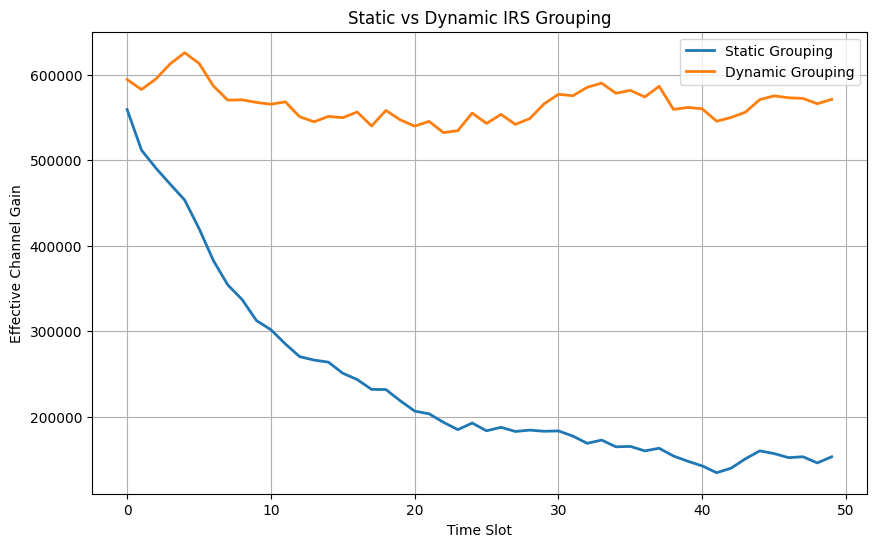

In [4]:
plt.figure(figsize=(10,6))

plt.plot(
    static_gains,
    label="Static Grouping",
    linewidth=2
)

plt.plot(
    dynamic_gains,
    label="Dynamic Grouping",
    linewidth=2
)

plt.xlabel("Time Slot")

plt.ylabel("Effective Channel Gain")

plt.title(
    "Static vs Dynamic IRS Grouping"
)

plt.grid(True)

plt.legend()

plt.savefig(
    "../results/figures/dynamic_grouping_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# to do laterrrrrrrrrrrr

# sparse_dynamic_gains = []
# rho = 0.98

# h_BI = h_BI_init.copy()
# h_IU = h_IU_init.copy()

In [ ]:
# to do laterrrrrrrrrrrr

""" for t in range(num_slots):

    noise_BI, noise_IU = generate_channels(M)

    h_BI = (
        rho*h_BI
        +
        np.sqrt(1-rho**2)*noise_BI
    )

    h_IU = (
        rho*h_IU
        +
        np.sqrt(1-rho**2)*noise_IU
    )

    cascaded = h_BI * h_IU

    strong_idx = strongest_elements(
        cascaded,
        keep_ratio=0.56
    )

    reduced_channel = cascaded[
        strong_idx
    ]

    groups = phase_grouping(
        reduced_channel,
        Q
    )

    h_sparse = grouped_channel(
        h_BI[strong_idx],
        h_IU[strong_idx],
        groups
    )

    sparse_dynamic_gains.append(
        abs(h_sparse)**2
    ) """